In [1]:
import matplotlib.pyplot as plt
import pandas as pd

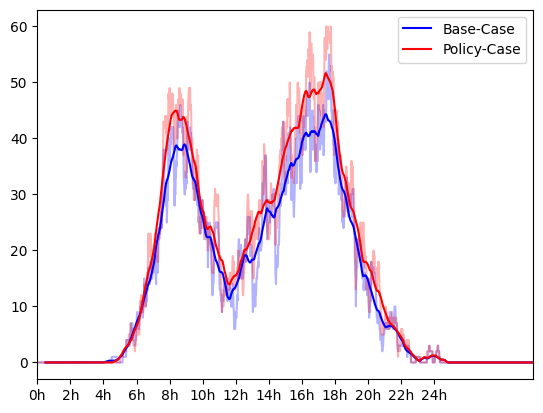

,Minute,Util_U2_base,Util_PT_base,Util_U2_policy,Util_PT_policy
0,0,0,0,0,0
1,1,0,0,0,0
2,2,0,0,0,0
3,3,0,0,0,0
4,4,0,0,0,0
...,...,...,...,...,...
2875,2875,0,0,0,0
2876,2876,0,0,0,0
2877,2877,0,0,0,0
2878,2878,0,0,0,0


In [3]:
data_base = pd.read_csv("pt_util_base.csv")
data_policy = pd.read_csv("pt_util_policy.csv")
data_base = data_base.rename(columns={"Util_U2": "Util_U2_base"})
data_policy = data_policy.rename(columns={"Util_U2": "Util_U2_policy"})
data_base = data_base.rename(columns={"Util_PT": "Util_PT_base"})
data_policy = data_policy.rename(columns={"Util_PT": "Util_PT_policy"})


data = pd.merge(data_base, data_policy, on="Minute")


fig, ax = plt.subplots()

ax.plot(data["Minute"],data["Util_U2_base"], color="blue",alpha= 0.3)
ax.plot(data["Minute"],data["Util_U2_policy"], color="red",alpha= 0.3)
ax.plot(data["Util_U2_base"].rolling(60,center=True).mean(), color="blue", alpha =1, label= "Base-Case")
ax.plot(data["Util_U2_policy"].rolling(60,center=True).mean(), color="red", alpha =1, label= "Policy-Case")


ticks_x = [i*120 for i in range(13)]
labels_x = [f"{i//60}h" for i in ticks_x]
ax.set_xlim(0, 30*60)
ax.set_xticks(ticks_x, labels_x)
ax.legend()
plt.show()
data

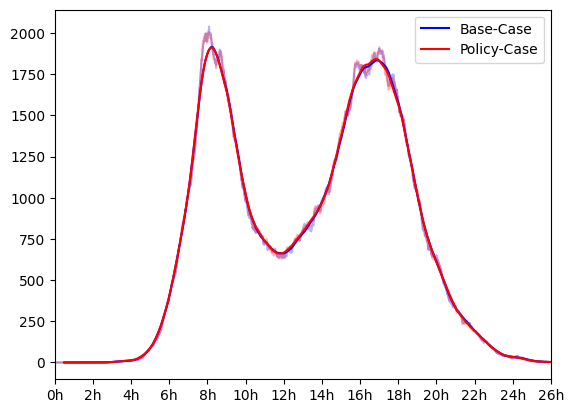

In [4]:
fig, ax = plt.subplots()

ax.plot(data["Minute"],data["Util_PT_base"], color="blue",alpha= 0.3)
ax.plot(data["Minute"],data["Util_PT_policy"], color="red",alpha= 0.3)
ax.plot(data["Util_PT_base"].rolling(60,center=True).mean(), color="blue", alpha =1, label= "Base-Case")
ax.plot(data["Util_PT_policy"].rolling(60,center=True).mean(), color="red", alpha =1, label= "Policy-Case")


ticks_x = [i*120 for i in range(14)]
labels_x = [f"{i//60}h" for i in ticks_x]
ax.set_xlim(0, 26*60)
ax.set_xticks(ticks_x, labels_x)
ax.legend()
plt.show()

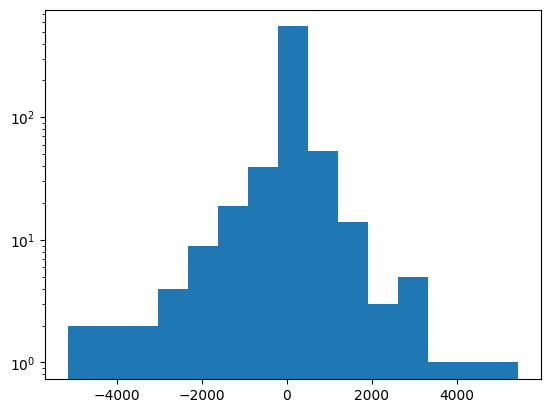

count      706.000000
mean      5292.837110
std       4006.027658
min         94.000000
25%       2361.000000
50%       4528.000000
75%       7299.750000
max      29741.000000
Name: TravelTime, dtype: float64
count      706.000000
mean      5276.658640
std       3969.570756
min         94.000000
25%       2340.250000
50%       4625.500000
75%       7381.000000
max      29119.000000
Name: TravelTime, dtype: float64
count     706.000000
mean       16.178470
std       752.472482
min     -5168.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      5457.000000
Name: time_save, dtype: float64


In [11]:
data_persons_base = pd.read_csv("persons_base.csv")
data_persons_policy = pd.read_csv("persons_policy.csv")



data_persons = pd.merge(data_persons_base, data_persons_policy, on="ID")
data_persons["time_save"] = data_persons["TravelTime_x"] - data_persons["TravelTime_y"]
fig, ax = plt.subplots()

ax.hist(data_persons["time_save"],15)
ax.set_yscale("log")

plt.show()
print(data_persons_base["TravelTime"].describe())
print(data_persons_policy["TravelTime"].describe())
print(data_persons["time_save"].describe())